In [26]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


# Logistic Regression

In [27]:
#coef_X = -2
#coef_intercept = -0.5

In [134]:
num = 10000
np.random.seed(0)
X = np.random.normal(0, 1, (num,))
true_prob = (X + 4) / 8
Y_random = np.random.binomial(1, true_prob)
model = LogisticRegression()
model.fit(X.reshape(-1, 1), Y_random)
print(model.coef_)
print(model.intercept_)

[[0.53725558]]
[-0.0075461]


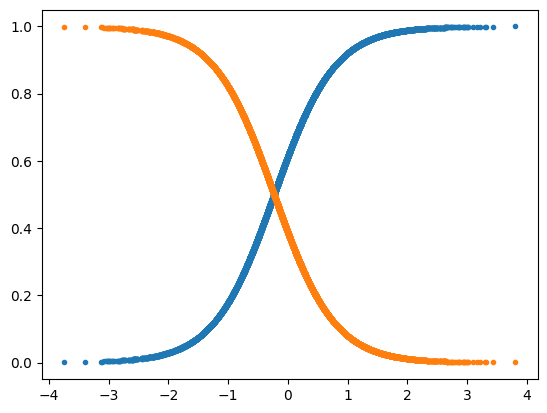

In [141]:
plt.plot(X, model.predict_proba(X.reshape(-1, 1)), ".")

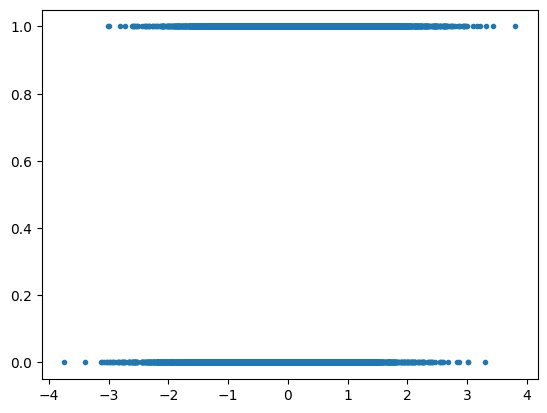

In [129]:
plt.plot(X, Y_random, ".")

In [145]:
-np.mean(Y_random * np.log(Y_pred) + (1 - Y_random) * np.log(1 - Y_pred))

0.46102107129920566

[[-1.98777471]]
[-0.46217235]


0.46102107129920566

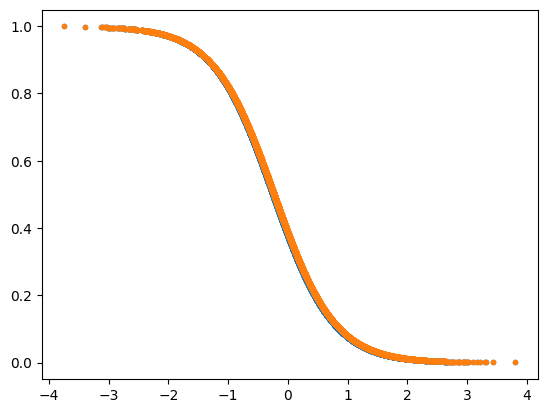

In [142]:
num = 10000
np.random.seed(0)
X_coef = -2
X_intercept = -0.5
X = np.random.normal(0, 1, (num,))
true_prob = 1 / (1 + np.exp(- X_coef * X - X_intercept))
Y_random = np.random.binomial(1, true_prob)
#df = pd.DataFrame({"true_prob": true_prob, "Y_random": Y_random})
#sns.boxplot(x = "Y_random", y = "true_prob", data=df)
model = LogisticRegression()
model.fit(X.reshape(-1, 1), Y_random)
Y_pred = model.predict_proba(X.reshape(-1, 1))[:,1]
plt.plot(X, true_prob, ".")
plt.plot(X, Y_pred, ".")
print(model.coef_)
print(model.intercept_)
log_loss(Y_random, Y_pred)

In [49]:
num = 10000
np.random.seed(0)
X = np.random.normal(0, 1, (num,))
true_prob = 1 / (1 + np.exp(2 * X + 0.5))
#true_prob = (X + 4) / 8
Y_random = np.random.binomial(1, true_prob)
model = LogisticRegression()
X_shaped = X.reshape(-1, 1)
model.fit(X_shaped, Y_random)
Y_pred = model.predict_proba(X_shaped)[:,1]
log_loss(Y_random, Y_pred)

0.46102107129920566

In [50]:
print(model.coef_)
print(model.intercept_)

[[-1.98777471]]
[-0.46217235]


In [51]:
np.argsort(X)
true_prob[np.argsort(X)]

array([9.99070748e-01, 9.98138668e-01, 9.96834908e-01, ...,
       8.13664293e-04, 6.38929634e-04, 3.02441431e-04])

In [62]:
sorted_idx = np.argsort(X)
X_sorted = X[sorted_idx]
Y_pred_sorted = Y_pred[sorted_idx]
true_prob_sorted = true_prob[sorted_idx]
#plt.plot(true_prob_sorted, Y_pred_sorted)
#plt.plot(X_sorted, Y_pred_sorted)
#plt.plot(X_sorted, true_prob_sorted, ".")

In [153]:
"""
num = 100
np.random.seed(0)
X = np.random.normal(0, 1, (num,))
true_prob = 1 / (1 + np.exp(2 * X + 0.5))
Y_random = np.random.binomial(1, true_prob)
model = LogisticRegression()
X_shaped = X.reshape(-1, 1)
model.fit(X_shaped, Y_random)
Y_pred = model.predict_proba(X_shaped)[:,1]
log_loss(Y_random, Y_pred)
"""

num = 100000
np.random.seed(0)
X1 = np.random.normal(0, 1, (num,))
X2 = np.random.normal(0, 1, (num,))
X = np.vstack((X1, X2)).T
X1_coef = -2
X2_coef = 1
intercept = -0.5
true_prob = 1 / (1 + np.exp(- X1_coef * X1 - X2_coef * X2 - intercept))
#true_prob = (X1 + X2 + 8) / 16
Y_random = np.random.binomial(1, true_prob)
model = LogisticRegression()
model.fit(X, Y_random)
Y_pred = model.predict_proba(X)[:,1]
log_loss(Y_random, Y_pred)

0.42857371408692646

In [154]:
print(model.coef_)
print(model.intercept_)

[[-2.0058711  0.9960015]]
[-0.5159457]


# Feature scaling

In [171]:
coefs

array([ 5.14246894e-01,  1.11286451e+00,  6.75024494e-01, -5.60556785e-01,
       -8.34898410e-01,  2.17193128e+00,  1.50300855e+00,  1.48913037e+00,
        6.53426551e-01,  2.09806839e-02, -4.00025552e-01,  9.57299458e-01,
       -2.28326856e-01,  8.43527395e-01,  9.34405961e-02, -6.99740861e-03,
        5.56167463e-01, -3.67812825e-03,  3.21893941e-01,  7.57950309e-01,
        3.30743201e-01,  7.25821375e-01, -5.20588040e-01, -4.64869896e-01,
       -1.30661644e+00, -1.81742923e-02, -5.99139724e-01, -1.31837252e+00,
       -5.78219672e-01, -1.28143907e+00,  1.75218190e+00,  4.25337086e-01,
       -2.09076912e+00, -4.75635866e-01, -4.87435936e-01, -1.33855518e+00,
        8.39503703e-01,  1.50693009e-01,  1.46253678e-01, -1.16337658e-01,
       -2.31206498e+00, -6.67157323e-01,  7.78148439e-01, -1.22117436e-01,
       -1.30157663e+00,  6.35837413e-01, -5.32107943e-01,  2.58823359e-01,
       -1.19061855e+00,  3.33585606e-01, -1.81915062e+00, -4.72121457e-01,
       -3.49123772e-01,  

In [170]:
num = 1000
cols = 1000
np.random.seed(0)
X = np.random.normal(0, 1, (num, cols))
coefs = np.random.normal(0, 1, (cols,))
Y = np.random.binomial(1, 1 / (1 + np.exp(X @ coefs)))
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3)
model = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 0.1)
model.fit(X_train, Y_train)
Y_pred = model.predict_proba(X_test)
log_loss(Y_test, Y_pred)

0.655056530292723

In [107]:
num = 1000
cols = 1000
np.random.seed(0)
X = np.random.normal(0, 1, (num, cols))
coefs = np.random.normal(0, 1, (cols,))
Y = np.random.binomial(1, 1 / (1 + np.exp(X @ coefs / np.std(X @ coefs))))
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3)
model = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 0.1)
model.fit(X_train, Y_train)
Y_pred = model.predict_proba(X_test)
log_loss(Y_test, Y_pred)

0.7272754451520161

In [8]:
num = 1000
cols = 1000
np.random.seed(0)
X = np.random.normal(0, 1, (num, cols))
coefs = np.random.normal(0, 1, (cols,))**4
Y = np.random.binomial(1, 1 / (1 + np.exp(X @ coefs / np.std(X @ coefs))))

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3)

model = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 0.1)
model.fit(X_train, Y_train)
Y_pred = model.predict_proba(X_test)
log_loss(Y_test, Y_pred)

0.6475315503198419

In [10]:
model2 = LogisticRegression()
model2.fit(X_train, Y_train)
Y_pred = model2.predict_proba(X_test)
log_loss(Y_test, Y_pred)

1.748520482797653

In [172]:
X_first_mult = X * np.hstack((10 * np.ones(500), np.ones(500)))
X_train, X_test, Y_train, Y_test = train_test_split(X_first_mult, Y, test_size=0.3)

model = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 0.1)
model.fit(X_train, Y_train)
Y_pred = model.predict_proba(X_test)
log_loss(Y_test, Y_pred)

1.878255015346546

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_first_mult)

In [173]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_first_mult)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.3)

model = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 0.1)
model.fit(X_train, Y_train)
Y_pred = model.predict_proba(X_test)
log_loss(Y_test, Y_pred)

0.6433364817754229

# Support Vector Machines

In [175]:
df = pd.DataFrame({"X1": pd.cut(X1, 5), "X2": pd.cut(X2, 5), "Y": Y})
pd.pivot_table(df, index = "X1", columns = "X2", values = "Y", aggfunc = "mean")

X2,"(-4.02, -2.405]","(-2.405, -0.799]","(-0.799, 0.807]","(0.807, 2.413]","(2.413, 4.019]"
X1,,,,,
"(-4.83, -3.099]",1.000,1.000000,0.333333,0.00000,NaN
"(-3.099, -1.377]",1.000,1.000000,0.484407,0.00000,0.000000
"(-1.377, 0.345]",0.775,0.757307,0.511421,0.23893,0.314815
"(0.345, 2.067]",0.000,0.000000,0.516302,1.00000,1.000000
"(2.067, 3.79]",0.000,0.000000,0.468750,1.00000,1.000000


In [174]:
num = 10000
X1 = np.random.normal(0, 1, (num,))
X2 = np.random.normal(0, 1, (num,))
Y = X1 * X2 + np.random.normal(0, 0.1, (num,)) > 0
X = np.vstack((X1, X2)).T

In [180]:
svc = SVC(kernel = 'poly', degree = 4, coef0 = 1)
svc.fit(X, Y)
(svc.predict(X) == Y).mean()

0.9159

In [8]:
svc2 = SVC(kernel = 'linear')
svc2.fit(X, Y)
(svc2.predict(X) == Y).sum()

6204

In [9]:
# High C = less regularization - points are not allowed to be misclassified
# Low C = more regularization - points are alloewd to be misclassified in the interest of a simpler model.

In [181]:
param_grid = {
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4]
}

grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X, Y)

# Best parameters
print("Best params", grid.best_params_)
# Best accuracy
print("Best CV accuracy", grid.best_score_)

best_model = grid.best_estimator_
train_accuracy = accuracy_score(Y, best_model.predict(X))
print("Train accuracy", train_accuracy)

Best params {'C': 0.1, 'degree': 3}
Best CV accuracy 0.9158000000000002
Train accuracy 0.9161
